In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('/home/jeanluca/code/JeanLucaSchindler/FUSE/raw_data/df_summaries.csv')

In [3]:
data = data.rename(columns={'Unnamed: 0':'ref'})

In [4]:
data

,ref,text,summary
0,E1.5.A.1.1_REF1_PSI,"""THE FOCUSSING ILLUSION. Any aspect of life to...","""THE FOCUSSING ILLUSION. Any aspect of life to..."
1,E1.5.A.1.1_REF2_PSI,"""MISWANTING"" ""Daniel Gilbert and Timothy Wilso...","""MISWANTING"" ""Daniel Gilbert and Timothy Wilso..."
2,E1.5.A.1.1_REF2.1_PH,NON-PHILOSOPHERS ARE UNABLE TO CHOOSE THE GOOD...,NON-PHILOSOPHERS ARE UNABLE TO CHOOSE THE GOOD...
3,E1.5.A.1.1_REF2.1.a_PH,"""IN PLATO'S MYTH OF ER THE PAMPHYLIAN, THE BAS...","""IN PLATO'S MYTH OF ER THE PAMPHYLIAN, THE BAS..."
4,E1.5.A.1.1_REF2.1.b_SONG,"JACQUES HIGELIN, TOMBÉ DU CIEL Listen to the ...","JACQUES HIGELIN, TOMBÉ DU CIEL Listen to the ..."
...,...,...,...
1901,E1.7.D.6.36_REF1_PO,"""BUT WE HAD MUSIC Right this minute across ti...","""BUT WE HAD MUSIC Right this minute across ti..."
1902,E1.7.D.6.37_REF1_SCI,"NATURAL SCENES ACTIVATE THE BRAIN'S ""DEFAULT M...","NATURAL SCENES ACTIVATE THE BRAIN'S ""DEFAULT M..."
1903,E1.7.D.6.38_REF1_LIT,"""A SENSE OF WONDER CAN FIND YOU IN MANY FORMS,...","""A SENSE OF WONDER CAN FIND YOU IN MANY FORMS,..."
1904,E1.7.D.6.39._REF1_LIT,"“IN LANGUAGE, ALL THINGS ARE POSSIBLE. Which m...","“IN LANGUAGE, ALL THINGS ARE POSSIBLE. Which m..."


In [5]:
from langdetect import detect, LangDetectException

In [6]:
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'


data['language'] = data['summary'].apply(detect_language)

In [7]:
tmp_data = data[data['language'] == 'en']
filtered_data = tmp_data[['summary']]

In [8]:
filtered_data.index = tmp_data.ref

In [9]:
filtered_data

,summary
ref,
E1.5.A.1.1_REF1_PSI,"""THE FOCUSSING ILLUSION. Any aspect of life to..."
E1.5.A.1.1_REF2_PSI,"""MISWANTING"" ""Daniel Gilbert and Timothy Wilso..."
E1.5.A.1.1_REF2.1_PH,NON-PHILOSOPHERS ARE UNABLE TO CHOOSE THE GOOD...
E1.5.A.1.1_REF2.1.a_PH,"""IN PLATO'S MYTH OF ER THE PAMPHYLIAN, THE BAS..."
E1.5.A.1.1_REF2.1.b_SONG,"JACQUES HIGELIN, TOMBÉ DU CIEL Listen to the ..."
...,...
E1.7.D.6.36_REF1_PO,"""BUT WE HAD MUSIC Right this minute across ti..."
E1.7.D.6.37_REF1_SCI,"NATURAL SCENES ACTIVATE THE BRAIN'S ""DEFAULT M..."
E1.7.D.6.38_REF1_LIT,"""A SENSE OF WONDER CAN FIND YOU IN MANY FORMS,..."


In [10]:
import string
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

def preprocessing(sentence):

    # Remove whitespace
    sentence = sentence.strip()

    # Lowercase characters
    sentence = sentence.lower()

    #stop_word
    stop_words = set(stopwords.words('english'))
    sentence = ' '.join(word for word in sentence.split() if word not in stop_words)

    # Remove numbers
    sentence = ''.join(char for char in sentence if not char.isdigit())

    # Remove punctuation
    for punctuation in string.punctuation:
        sentence = sentence.replace(punctuation, '')

    # Tokenize
    sentence = word_tokenize(sentence)

    # Lemmatize
    verbs_lemmed = [
        WordNetLemmatizer().lemmatize(word, pos='v')
        for word in sentence
    ]
    nouns_lemmed = [
        WordNetLemmatizer().lemmatize(word, pos='n')
        for word in verbs_lemmed
    ]
    return ' '.join(word for word in nouns_lemmed)

In [11]:
filtered_data['clean_text'] = filtered_data.summary.apply(preprocessing)

/tmp/ipykernel_184446/3578068794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['clean_text'] = filtered_data.summary.apply(preprocessing)


In [59]:
filtered_data.head(20)

,summary,clean_text
ref,,
E1.5.A.1.1_REF1_PSI,"""THE FOCUSSING ILLUSION. Any aspect of life to...",the focus illusion aspect life attention direc...
E1.5.A.1.1_REF2_PSI,"""MISWANTING"" ""Daniel Gilbert and Timothy Wilso...",miswanting daniel gilbert timothy wilson intro...
E1.5.A.1.1_REF2.1_PH,NON-PHILOSOPHERS ARE UNABLE TO CHOOSE THE GOOD...,nonphilosophers unable choose good life plato ...
E1.5.A.1.1_REF2.1.a_PH,"""IN PLATO'S MYTH OF ER THE PAMPHYLIAN, THE BAS...",in plato myth er pamphylian basic question hap...
E1.5.A.1.1_REF2.1.b_SONG,"JACQUES HIGELIN, TOMBÉ DU CIEL Listen to the ...",jacques higelin tombé du ciel listen song yout...
E1.5.A.1.1_REF2.2_PH,"MISWANTING, AS CONCEPTUALIZED BY DANIEL GILBER...",miswanting conceptualize daniel gilbert timoth...
E1.5.A.1.1_REF2.2.a_PH,"""PROPOSITION 51 Different men may be different...",proposition different men may differently affe...
E1.5.A.1.2_REF1_PSI,"""GO AHEAD AND TAKE A PENCIL, AND HOLD IT BETWE...",go ahead take pencil hold teeth second eraser ...
E1.5.A.1.2_REF2_PH,"""THE CUSTOMS OF POLITENESS ARE VERY POWERFUL O...",the custom politeness powerful thought small h...


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

count_df = count_vectorizer.fit_transform(filtered_data['clean_text'])
count_df = pd.DataFrame(count_df.toarray())
count_df

,0,1,2,3,4,5,6,7,8,9,...,6868,6869,6870,6871,6872,6873,6874,6875,6876,6877
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1233,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1234,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
from sklearn.decomposition import TruncatedSVD

In [15]:
svd = TruncatedSVD(n_components=615)
trunc_df = svd.fit_transform(count_df)

In [16]:
print(svd.explained_variance_ratio_.sum())

0.8966308473930422


In [17]:
import matplotlib.pyplot as plt

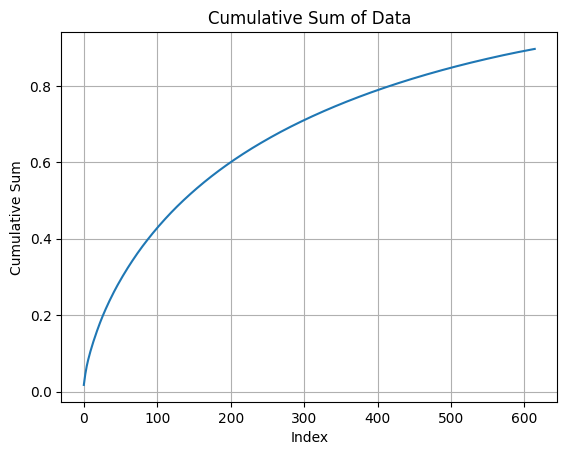

In [18]:
# Calculate the cumulative sum
cumulative_data = np.cumsum(svd.explained_variance_ratio_)

# Plot the cumulative sum
plt.plot(cumulative_data)
plt.title('Cumulative Sum of Data')
plt.xlabel('Index')
plt.ylabel('Cumulative Sum')
plt.grid(True)
plt.show()

In [19]:
trunc_df = pd.DataFrame(trunc_df, columns=[f'component_{i+1}' for i in range(trunc_df.shape[1])])
latent_df = trunc_df.set_index(filtered_data.index)
latent_df

,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8,component_9,component_10,...,component_606,component_607,component_608,component_609,component_610,component_611,component_612,component_613,component_614,component_615
ref,,,,,,,,,,,,,,,,,,,,,
E1.5.A.1.1_REF1_PSI,1.197769,-1.124953,-0.304797,-0.935056,-0.484383,0.302672,0.132085,-0.164532,-0.743645,0.160522,...,0.041599,0.180032,-0.015532,-0.143219,-0.040843,0.261641,0.005289,0.064968,0.000088,0.070728
E1.5.A.1.1_REF2_PSI,0.160286,-0.058914,-0.044714,0.043185,0.012707,-0.007525,0.102991,-0.020255,0.006339,-0.090149,...,-0.098499,-0.060173,0.010823,-0.085725,0.118481,0.338262,-0.150869,0.119033,-0.066430,-0.005737
E1.5.A.1.1_REF2.1_PH,0.805873,-1.099289,-0.493103,-1.068480,-0.329597,0.404369,0.057117,0.242600,-0.302927,0.218156,...,0.156391,-0.039359,-0.253749,0.064189,-0.071529,0.160387,-0.176139,0.115009,-0.041708,0.081122
E1.5.A.1.1_REF2.1.a_PH,0.896746,-1.065829,-0.517179,-1.188183,-0.281173,0.505202,0.098311,0.503328,-0.469456,0.058589,...,-0.174742,-0.155488,0.207701,0.179704,-0.039170,-0.162973,-0.076979,0.033163,-0.087514,0.058615
E1.5.A.1.1_REF2.1.b_SONG,0.038517,-0.011249,-0.006414,-0.011639,-0.020795,-0.052559,-0.028001,-0.019859,-0.015475,-0.015241,...,0.025616,-0.213634,0.020636,-0.118818,0.034985,-0.057580,0.028326,0.103509,0.078094,-0.016993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E1.7.D.6.36_REF1_PO,0.836125,-0.450028,-0.007264,0.141965,-0.302197,-1.214133,-0.147015,-1.081288,0.205427,0.120444,...,-0.015657,-0.151020,-0.007678,0.137130,0.011560,-0.048866,0.050868,0.046048,-0.003581,0.009999
E1.7.D.6.37_REF1_SCI,0.557634,-0.253283,-0.009894,0.442023,0.175116,-0.282400,0.749800,-0.067395,-0.147809,0.340997,...,0.043807,-0.002868,0.048071,-0.103530,0.037781,0.206658,0.003996,0.118355,0.073295,0.136709
E1.7.D.6.38_REF1_LIT,3.144902,1.196055,0.784851,1.028680,-1.080974,-0.084632,-1.757700,-0.194798,0.964538,-1.274081,...,-0.053969,-0.019347,-0.009004,0.012362,0.004863,0.019297,-0.004861,-0.000533,-0.026645,0.012344


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

In [60]:
# Compute cosine similarity for content matrix
content_similarities = cosine_similarity(np.array(latent_df.iloc[7]).reshape(1, -1), latent_df).flatten()


In [61]:
reco = pd.DataFrame(content_similarities)
reco = reco.set_index(filtered_data.index)
reco = reco.rename(columns={0:'similarity'})

In [62]:
reco

,similarity
ref,
E1.5.A.1.1_REF1_PSI,0.000704
E1.5.A.1.1_REF2_PSI,-0.003633
E1.5.A.1.1_REF2.1_PH,-0.004627
E1.5.A.1.1_REF2.1.a_PH,-0.000933
E1.5.A.1.1_REF2.1.b_SONG,-0.008095
...,...
E1.7.D.6.36_REF1_PO,0.057300
E1.7.D.6.37_REF1_SCI,0.000430
E1.7.D.6.38_REF1_LIT,0.019692


In [63]:
top_reco = reco.sort_values(by=['similarity'], ascending=False).head(5)

In [64]:
top_reco

,similarity
ref,
E1.5.A.1.2_REF1_PSI,1.000000
E1.7.D.5.4.b_REF3_PH,0.250578
E1.7.D.6.9_REF1_PO,0.219355
E1.7.A.3.1_REF3_PO,0.215425
E1.7.B.2.4.d.i_REF2_CUR,0.178998


In [65]:
filtered_data.loc[top_reco.index[0]]['summary']

'"GO AHEAD AND TAKE A PENCIL, AND HOLD IT BETWEEN YOUR TEETH for a few seconds with the eraser pointing to your right and the point to your left. Now hold the pencil so the point is aimed straight in front of you, by pursuing your lips around the eraser end.'

In [66]:
filtered_data.loc[top_reco.index[1]]['summary']

'"AT THE POINT OF REST OF THE WHIRLING WORLD, neither flesh, nor deprivation of flesh, neither « coming from »  nor « going to », at the point of rest : there is the dance. Neither stop, nor move.'